## Util

In [1]:
%load_ext autoreload
%autoreload 2

## Core model

In [9]:
import torch
import torch.nn as nn

class ScamGuardLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super(ScamGuardLSTM, self).__init__()
        
        # 1. Embedding Layer: Converts token integers into dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # 2. LSTM Layer: The sequential "memory" of the model
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )
        
        # 3. Fully Connected Layer: Maps the LSTM output to our classes (0 = Safe, 1 = Scam)
        # Multiply hidden_dim by 2 because it's bidirectional
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        
        # 4. Dropout: Regularization to prevent overfitting on small datasets
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
        # text shape: [batch_size, sequence_length]
        embedded = self.dropout(self.embedding(text))

        # Ensure lengths are at least 1 and on CPU for packing
        text_lengths = text_lengths.clamp(min=1).cpu()
        
        # Pack sequence to handle variable message lengths efficiently in memory
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, text_lengths, batch_first=True, enforce_sorted=False
        )
        
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        
        # Extract the final hidden state from both the forward and backward passes
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        else:
            hidden = self.dropout(hidden[-1,:,:])
            
        # Pass through the linear layer for the final logit prediction
        return self.fc(hidden)


## Data preprocessing

In [2]:
import sys

from data_loader import load_scam_data, load_embeddings

dataset = load_scam_data()
glove = load_embeddings()

glove_weights = glove.vectors

/opt/anaconda3/envs/cs3264-project-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading/Loading SMS Spam dataset...



Sample Data Structure:
{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n', 'label': 0}

Downloading/Loading GloVe Embeddings...
(Note: This is an ~800MB download the first time you run it. Grab a coffee.)

The shape of the word vector for 'scam' is: torch.Size([100])


### Tokenize and build vocabulary

In [3]:
import torch
from collections import Counter

# 1. Flatten all messages to count word frequency
all_text = " ".join(dataset['train']['sms']).lower().split()
word_counts = Counter(all_text)

# 2. Create a vocabulary (only keep words that appear at least twice)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counts.items():
    if count > 1:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 5545


### Create embedding matrix

In [4]:
embedding_dim = 100
# Initialize matrix with zeros or random numbers
target_vocab_size = len(vocab)
embedding_matrix = torch.zeros((target_vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in glove.stoi: # Check if word exists in GloVe
        embedding_matrix[idx] = glove.vectors[glove.stoi[word]]
    else:
        # For <UNK> or missing words, use a random normal vector
        embedding_matrix[idx] = torch.randn(embedding_dim)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: torch.Size([5545, 100])


### Numericalize and pad sequences

In [5]:
def encode_and_pad(text, max_len=50):
    tokens = text.lower().split()
    # Convert words to indices
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    # Pad or Truncate
    if len(indices) < max_len:
        indices += [vocab["<PAD>"]] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Apply to the dataset
train_data = [encode_and_pad(msg) for msg in dataset['train']['sms']]
train_labels = dataset['train']['label'] # 0 for ham, 1 for spam

# Convert to Tensors
X_train = torch.tensor(train_data)
y_train = torch.tensor(train_labels)

In [6]:
from torch.utils.data import TensorDataset, DataLoader

# 1. Split the original Hugging Face dataset (if you haven't already)
# This creates a 80/20 split
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

# 2. Process Training Data (Re-doing this to ensure consistency)
train_msgs = [encode_and_pad(msg) for msg in split_dataset['train']['sms']]
train_labels = split_dataset['train']['label']
X_train = torch.tensor(train_msgs)
y_train = torch.tensor(train_labels)

# 3. Process Test Data (The missing piece!)
test_msgs = [encode_and_pad(msg) for msg in split_dataset['test']['sms']]
test_labels = split_dataset['test']['label']
X_test = torch.tensor(test_msgs)
y_test = torch.tensor(test_labels)

# 4. Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle test data

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

Train samples: 4459, Test samples: 1115


### Wrap in dataloader

In [7]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Test a batch
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}") # Should be [32, 50]

Batch X shape: torch.Size([32, 50])


## Training

In [10]:
import torch.optim as optim
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ScamGuardLSTM(
    vocab_size=len(glove.stoi), 
    embedding_dim=100, 
    hidden_dim=256, 
    output_dim=1, 
    n_layers=2, 
    bidirectional=True, 
    dropout=0.5
)
model.embedding.weight.data.copy_(glove_weights) # Load pre-trained GloVe
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss() # Best for binary classification (Scam vs. Safe)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        
        # Calculate lengths: count how many non-zero tokens are in each row
        # (Assuming 0 is your <PAD> token index)
        lengths = (texts != 0).sum(dim=1).cpu() 
        
        optimizer.zero_grad()
        
        # Pass both arguments to the model
        predictions = model(texts, lengths).squeeze(1) 
        
        loss = criterion(predictions, labels.float())
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        preds = torch.round(torch.sigmoid(predictions))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return epoch_loss / len(loader), correct / total

In [30]:
N_EPOCHS = 10
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    # valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    
    # Save the best model for the final report
    if train_loss < best_valid_loss:
        best_valid_loss = train_loss
        torch.save(model.state_dict(), 'scam-guard-lstm.pt')

Epoch: 01
	Train Loss: 0.285 | Train Acc: 89.26%
Epoch: 02
	Train Loss: 0.145 | Train Acc: 95.04%
Epoch: 03
	Train Loss: 0.092 | Train Acc: 96.86%
Epoch: 04
	Train Loss: 0.068 | Train Acc: 97.94%
Epoch: 05
	Train Loss: 0.060 | Train Acc: 98.05%
Epoch: 06
	Train Loss: 0.047 | Train Acc: 98.47%
Epoch: 07
	Train Loss: 0.037 | Train Acc: 98.70%
Epoch: 08
	Train Loss: 0.036 | Train Acc: 98.86%
Epoch: 09
	Train Loss: 0.029 | Train Acc: 99.01%
Epoch: 10
	Train Loss: 0.016 | Train Acc: 99.48%


In [16]:
def evaluate(model, loader, criterion, device):
    model.eval() # Set model to evaluation mode
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Disable gradient calculation for efficiency and to ensure no learning happens
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            
            # Re-calculate lengths for the packed sequence
            lengths = (texts != 0).sum(dim=1).cpu()
            
            # Forward pass
            predictions = model(texts, lengths).squeeze(1)
            
            # Calculate loss
            loss = criterion(predictions, labels.float())
            
            epoch_loss += loss.item()
            
            # Convert logits to probabilities (0 to 1) and then to binary (0 or 1)
            preds = torch.round(torch.sigmoid(predictions))
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return epoch_loss / len(loader), correct / total

In [32]:
valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train

In [33]:
print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc*100:.2f}%')

	Valid Loss: 0.073 | Valid Acc: 98.39%


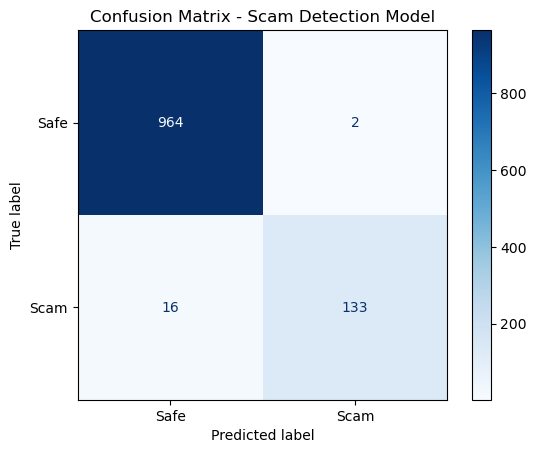

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Scam"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Scam Detection Model")
plt.show()

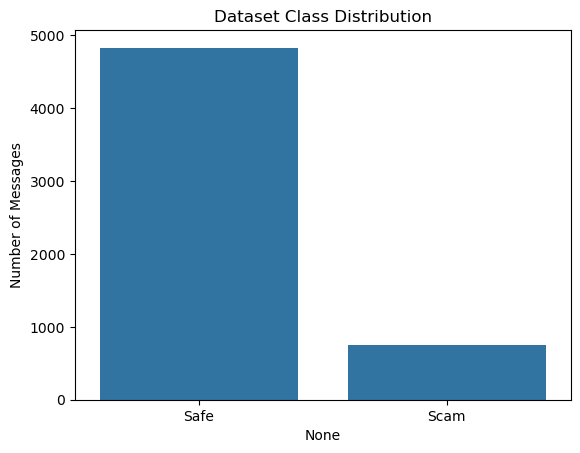

In [37]:
import seaborn as sns
import pandas as pd

labels_df = pd.Series(dataset['train']['label'])

sns.countplot(x=labels_df)
plt.xticks([0,1], ["Safe", "Scam"])
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Messages")
plt.show()

Epoch 1: Loss 0.018
Epoch 2: Loss 0.021
Epoch 3: Loss 0.017
Epoch 4: Loss 0.009
Epoch 5: Loss 0.012
Epoch 6: Loss 0.009
Epoch 7: Loss 0.015
Epoch 8: Loss 0.010
Epoch 9: Loss 0.009
Epoch 10: Loss 0.007


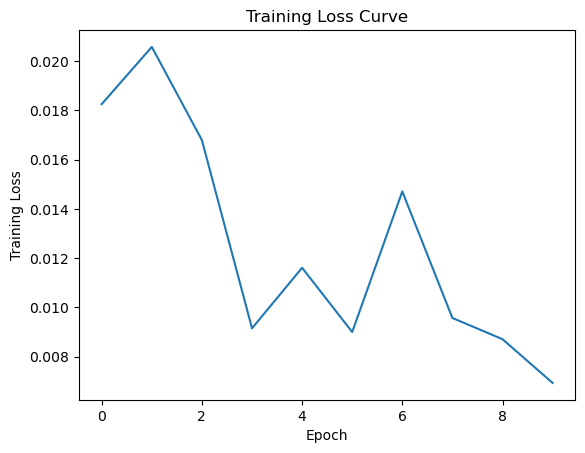

In [38]:
train_losses = []

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    train_losses.append(train_loss)

    print(f'Epoch {epoch+1}: Loss {train_loss:.3f}')

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

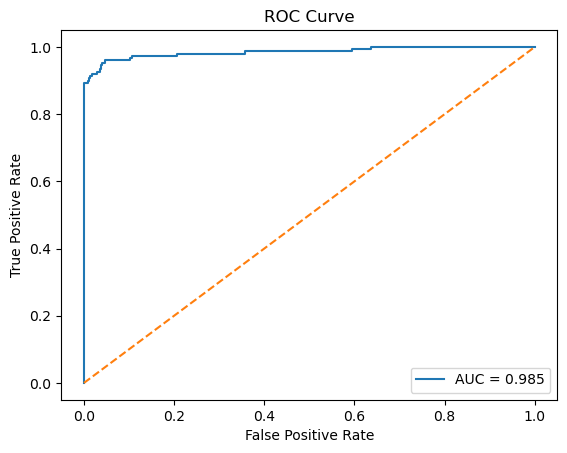

In [39]:
from sklearn.metrics import roc_curve, auc

all_probs = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        probs = torch.sigmoid(predictions)

        all_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)

        alpha_t = torch.where(
            targets == 1,
            torch.full_like(targets, self.alpha),
            torch.full_like(targets, 1 - self.alpha)
        )

        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [58]:
model = ScamGuardLSTM(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    output_dim=1,
    n_layers=2,
    bidirectional=True,
    dropout=0.5
)
model.embedding.weight.data.copy_(embedding_matrix)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
#criterion = nn.BCEWithLogitsLoss() # Best for binary classification (Scam vs. Safe)
criterion = FocalLoss(alpha=0.75, gamma=2.0)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        
        # Calculate lengths: count how many non-zero tokens are in each row
        # (Assuming 0 is your <PAD> token index)
        lengths = (texts != 0).sum(dim=1).cpu() 
        
        optimizer.zero_grad()
        
        # Pass both arguments to the model
        predictions = model(texts, lengths).squeeze(1) 
        
        loss = criterion(predictions, labels.float())
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        preds = torch.round(torch.sigmoid(predictions))
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return epoch_loss / len(loader), correct / total

In [62]:
N_EPOCHS = 10
best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    # valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    
    # Save the best model for the final report
    if train_loss < best_valid_loss:
        best_valid_loss = train_loss
        torch.save(model.state_dict(), 'scam-guard-lstm.pt')

Epoch: 01
	Train Loss: 0.287 | Train Acc: 88.29%
Epoch: 02
	Train Loss: 0.146 | Train Acc: 94.46%
Epoch: 03
	Train Loss: 0.117 | Train Acc: 95.90%
Epoch: 04
	Train Loss: 0.089 | Train Acc: 97.04%
Epoch: 05
	Train Loss: 0.074 | Train Acc: 97.24%
Epoch: 06
	Train Loss: 0.044 | Train Acc: 98.32%
Epoch: 07
	Train Loss: 0.034 | Train Acc: 98.79%
Epoch: 08
	Train Loss: 0.031 | Train Acc: 98.79%
Epoch: 09
	Train Loss: 0.041 | Train Acc: 98.79%
Epoch: 10
	Train Loss: 0.015 | Train Acc: 99.48%


In [63]:
valid_loss, valid_acc = evaluate(model, test_loader, criterion, device) # Define similar to train

In [64]:
print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc: {valid_acc*100:.2f}%')

	Valid Loss: 0.116 | Valid Acc: 97.31%


In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

def compute_metrics(model, loader, device):
    
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for texts, labels in loader:
            
            texts = texts.to(device)
            labels = labels.to(device)
            
            lengths = (texts != 0).sum(dim=1).cpu()
            
            logits = model(texts, lengths).squeeze(1)
            
            probs = torch.sigmoid(logits)
            preds = torch.round(probs)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, all_preds)
    
    print("\nEvaluation Metrics")
    print("-------------------")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    print("\nClassification Report")
    print(classification_report(all_labels, all_preds))
    
    print("\nConfusion Matrix")
    print(confusion_matrix(all_labels, all_preds))
    
    return precision, recall, f1, acc

In [66]:
compute_metrics(model, test_loader, device)


Evaluation Metrics
-------------------
Accuracy  : 0.9731
Precision : 0.9048
Recall    : 0.8926
F1 Score  : 0.8986

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       966
           1       0.90      0.89      0.90       149

    accuracy                           0.97      1115
   macro avg       0.94      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix
[[952  14]
 [ 16 133]]


(0.9047619047619048,
 0.8926174496644296,
 0.8986486486486487,
 0.9730941704035875)

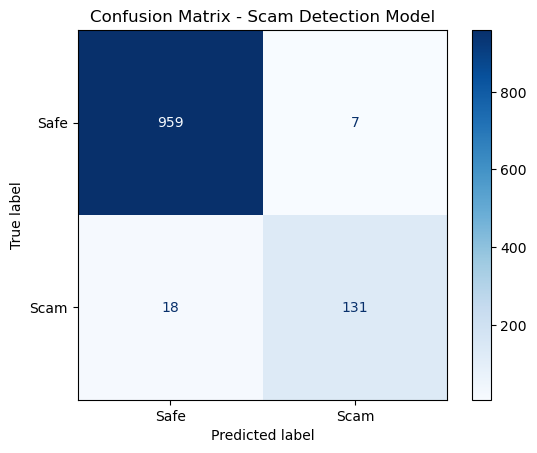

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        predictions = model(texts, lengths).squeeze(1)
        preds = torch.round(torch.sigmoid(predictions))

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe", "Scam"])
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Scam Detection Model")
plt.show()

In [43]:
## Re Sampling

In [46]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import torch

batch_size = 32

# Build TensorDataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Count examples in each class
class_counts = torch.bincount(y_train)
print("Class counts:", class_counts.tolist())   # [num_safe, num_scam]

# Inverse frequency = higher weight for minority class
class_weights = 1.0 / class_counts.float()
print("Class weights:", class_weights.tolist())

# Assign each training sample a weight based on its label
sample_weights = class_weights[y_train]

# Weighted sampler for training only
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Train loader uses sampler instead of shuffle=True
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler
)

# Test loader stays normal
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Quick batch check
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}")
print(f"Batch label distribution: {torch.bincount(sample_y).tolist()}")

Class counts: [3861, 598]
Class weights: [0.0002590002550277859, 0.0016722407890483737]
Batch X shape: torch.Size([32, 50])
Batch label distribution: [15, 17]


In [61]:
import torch
import torch.optim as optim
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ScamGuardLSTM(
    vocab_size=len(vocab),
    embedding_dim=100,
    hidden_dim=256,
    output_dim=1,
    n_layers=2,
    bidirectional=True,
    dropout=0.5
)

model.embedding.weight.data.copy_(embedding_matrix)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [68]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# =========================================================
# 1. DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# 2. OPTIONAL MODEL TWEAK
#    If your class definition already exists, keep it.
#    Just make sure embedding uses padding_idx=0 if possible.
# =========================================================
# Recommended version for reference:
#
class ScamGuardLSTM(nn.Module):
     def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
         super().__init__()
         self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
         self.lstm = nn.LSTM(
             input_size=embedding_dim,
             hidden_size=hidden_dim,
             num_layers=n_layers,
             bidirectional=bidirectional,
             dropout=dropout if n_layers > 1 else 0.0,
             batch_first=True
         )
         self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
         self.dropout = nn.Dropout(dropout)

     def forward(self, text, text_lengths):
         embedded = self.dropout(self.embedding(text))
         text_lengths = text_lengths.clamp(min=1).cpu()
         packed_embedded = nn.utils.rnn.pack_padded_sequence(
             embedded, text_lengths, batch_first=True, enforce_sorted=False
         )
         packed_output, (hidden, cell) = self.lstm(packed_embedded)

         if self.lstm.bidirectional:
             hidden = self.dropout(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
         else:
             hidden = self.dropout(hidden[-1, :, :])

         return self.fc(hidden)

# =========================================================
# 3. FOCAL LOSS
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.85, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()

        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(
            targets == 1,
            torch.full_like(targets, self.alpha),
            torch.full_like(targets, 1 - self.alpha)
        )

        loss = alpha_t * ((1 - pt) ** self.gamma) * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

# =========================================================
# 4. DATALOADERS
#    We will create:
#    - normal train loader
#    - resampled train loader
#    - normal test loader
# =========================================================
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Normal train loader
train_loader_normal = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Resampled train loader
class_counts = torch.bincount(y_train)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train]

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_resampled = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=weighted_sampler
)

# Test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Class counts:", class_counts.tolist())

# =========================================================
# 5. MODEL FACTORY
#    Creates a fresh model each time
# =========================================================
def build_model(freeze_embeddings=False):
    model = ScamGuardLSTM(
        vocab_size=len(vocab),
        embedding_dim=100,
        hidden_dim=256,
        output_dim=1,
        n_layers=2,
        bidirectional=True,
        dropout=0.5
    )

    model.embedding.weight.data.copy_(embedding_matrix)

    if freeze_embeddings:
        model.embedding.weight.requires_grad = False

    return model.to(device)

# =========================================================
# 6. TRAIN / EVAL HELPERS
# =========================================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    for texts, labels in loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()

        optimizer.zero_grad()
        logits = model(texts, lengths).squeeze(1)
        loss = criterion(logits, labels.float())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return epoch_loss / len(loader), correct / total


def evaluate_loss_accuracy(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            lengths = (texts != 0).sum(dim=1).cpu()
            logits = model(texts, lengths).squeeze(1)

            loss = criterion(logits, labels.float())
            epoch_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return epoch_loss / len(loader), correct / total


def collect_probs_labels(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            lengths = (texts != 0).sum(dim=1).cpu()
            logits = model(texts, lengths).squeeze(1)
            probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)


def compute_metrics_from_probs(all_probs, all_labels, threshold=0.5):
    preds = (all_probs >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(all_labels, preds),
        "precision": precision_score(all_labels, preds, zero_division=0),
        "recall": recall_score(all_labels, preds, zero_division=0),
        "f1": f1_score(all_labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(all_labels, preds)
    }

# =========================================================
# 7. TRAINING FUNCTION
#    Trains one model configuration
# =========================================================
def train_model(
    model_name,
    train_loader,
    criterion,
    freeze_embeddings=False,
    n_epochs=10,
    lr=1e-3
):
    model = build_model(freeze_embeddings=freeze_embeddings)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_valid_loss = float("inf")
    history = []

    print(f"\n===== Training: {model_name} =====")

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate_loss_accuracy(model, test_loader, criterion, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "valid_loss": valid_loss,
            "valid_acc": valid_acc
        })

        print(
            f"Epoch {epoch+1:02} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}"
        )

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

# =========================================================
# 8. DEFINE MODELS TO TRY
#    You can edit this list if needed.
#    These preserve LSTM and compare:
#    - BCE baseline
#    - weighted BCE
#    - focal loss
#    - resampling
#    - freeze embeddings
# =========================================================
num_neg = (y_train == 0).sum().item()
num_pos = (y_train == 1).sum().item()
pos_weight = torch.tensor([num_neg / num_pos], device=device)

experiments = [
    {
        "name": "BCE_Normal",
        "train_loader": train_loader_normal,
        "criterion": nn.BCEWithLogitsLoss(),
        "freeze_embeddings": False
    },
    {
        "name": "WeightedBCE_Normal",
        "train_loader": train_loader_normal,
        "criterion": nn.BCEWithLogitsLoss(pos_weight=pos_weight),
        "freeze_embeddings": False
    },
    {
        "name": "Focal_Normal",
        "train_loader": train_loader_normal,
        "criterion": FocalLoss(alpha=0.85, gamma=2.0),
        "freeze_embeddings": False
    },
    {
        "name": "WeightedBCE_Resampled",
        "train_loader": train_loader_resampled,
        "criterion": nn.BCEWithLogitsLoss(pos_weight=pos_weight),
        "freeze_embeddings": False
    },
    {
        "name": "Focal_Resampled",
        "train_loader": train_loader_resampled,
        "criterion": FocalLoss(alpha=0.85, gamma=2.0),
        "freeze_embeddings": False
    },
    {
        "name": "WeightedBCE_Normal_FrozenEmb",
        "train_loader": train_loader_normal,
        "criterion": nn.BCEWithLogitsLoss(pos_weight=pos_weight),
        "freeze_embeddings": True
    }
]

# =========================================================
# 9. TRAIN ALL MODELS
# =========================================================
trained_models = {}
histories = {}

for exp in experiments:
    model, history_df = train_model(
        model_name=exp["name"],
        train_loader=exp["train_loader"],
        criterion=exp["criterion"],
        freeze_embeddings=exp["freeze_embeddings"],
        n_epochs=10,
        lr=1e-3
    )
    trained_models[exp["name"]] = model
    histories[exp["name"]] = history_df

# =========================================================
# 10. THRESHOLD SWEEP
#     We now test many thresholds for each trained model.
# =========================================================
thresholds = np.arange(0.30, 0.71, 0.05)

all_results = []

for model_name, model in trained_models.items():
    probs, labels = collect_probs_labels(model, test_loader, device)

    for threshold in thresholds:
        metrics = compute_metrics_from_probs(probs, labels, threshold=threshold)
        metrics["model"] = model_name
        all_results.append(metrics)

results_df = pd.DataFrame(all_results)

# Clean display
display_cols = ["model", "threshold", "accuracy", "precision", "recall", "f1"]
results_display = results_df[display_cols].sort_values(
    by=["recall", "accuracy", "f1"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n===== All model/threshold results sorted by recall, accuracy, f1 =====")
print(results_display)

# =========================================================
# 11. PICK A BEST MODEL
#     You said the priority is recall, but accuracy should remain good.
#     So we can filter first by accuracy floor, then pick highest recall.
# =========================================================
accuracy_floor = 0.96   # adjust if you want
filtered_df = results_df[results_df["accuracy"] >= accuracy_floor].copy()

if len(filtered_df) > 0:
    best_row = filtered_df.sort_values(
        by=["recall", "f1", "accuracy", "precision"],
        ascending=[False, False, False, False]
    ).iloc[0]
else:
    best_row = results_df.sort_values(
        by=["recall", "f1", "accuracy", "precision"],
        ascending=[False, False, False, False]
    ).iloc[0]

print("\n===== Selected Best Configuration =====")
print(best_row[display_cols])

best_model_name = best_row["model"]
best_threshold = float(best_row["threshold"])
best_model = trained_models[best_model_name]

# =========================================================
# 12. FINAL REPORT ON BEST MODEL
# =========================================================
best_probs, best_labels = collect_probs_labels(best_model, test_loader, device)
best_preds = (best_probs >= best_threshold).astype(int)

print("\n===== Classification Report (Best Model) =====")
print(classification_report(best_labels, best_preds, target_names=["Safe", "Scam"], zero_division=0))

print("\n===== Confusion Matrix (Best Model) =====")
print(confusion_matrix(best_labels, best_preds))

# =========================================================
# 13. SAVE BEST MODEL
# =========================================================
torch.save(
    {
        "model_name": best_model_name,
        "threshold": best_threshold,
        "state_dict": best_model.state_dict()
    },
    "best_scam_guard_lstm.pt"
)

print("\nSaved best model to best_scam_guard_lstm.pt")

Using device: cpu
Class counts: [3861, 598]

===== Training: BCE_Normal =====
Epoch 01 | Train Loss: 0.2260 | Train Acc: 0.9143 | Valid Loss: 0.1360 | Valid Acc: 0.9561
Epoch 02 | Train Loss: 0.1195 | Train Acc: 0.9585 | Valid Loss: 0.1198 | Valid Acc: 0.9480
Epoch 03 | Train Loss: 0.0874 | Train Acc: 0.9697 | Valid Loss: 0.0905 | Valid Acc: 0.9749
Epoch 04 | Train Loss: 0.0639 | Train Acc: 0.9821 | Valid Loss: 0.0839 | Valid Acc: 0.9731
Epoch 05 | Train Loss: 0.0508 | Train Acc: 0.9852 | Valid Loss: 0.0743 | Valid Acc: 0.9785
Epoch 06 | Train Loss: 0.0443 | Train Acc: 0.9861 | Valid Loss: 0.0726 | Valid Acc: 0.9776
Epoch 07 | Train Loss: 0.0419 | Train Acc: 0.9868 | Valid Loss: 0.0848 | Valid Acc: 0.9821
Epoch 08 | Train Loss: 0.0312 | Train Acc: 0.9897 | Valid Loss: 0.0703 | Valid Acc: 0.9767
Epoch 09 | Train Loss: 0.0201 | Train Acc: 0.9944 | Valid Loss: 0.0911 | Valid Acc: 0.9758
Epoch 10 | Train Loss: 0.0221 | Train Acc: 0.9919 | Valid Loss: 0.0750 | Valid Acc: 0.9848

===== Train

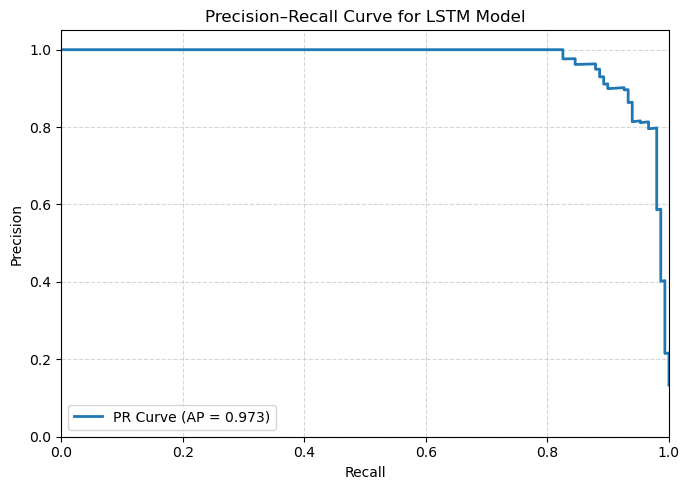

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Collect probabilities and labels from the best model
best_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)

        lengths = (texts != 0).sum(dim=1).cpu()
        logits = best_model(texts, lengths).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, label=f"PR Curve (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve for LSTM Model")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

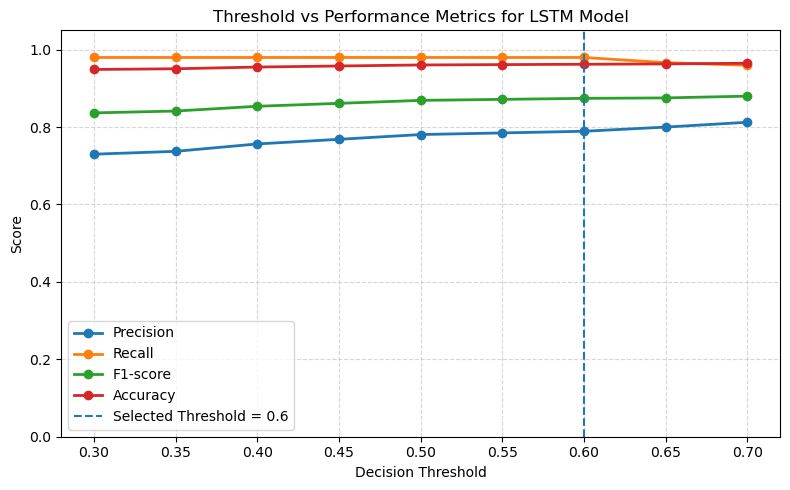

In [80]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter only the best model rows
best_model_name = "WeightedBCE_Resampled"
plot_df = results_df[results_df["model"] == best_model_name].copy()
plot_df = plot_df.sort_values("threshold")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(plot_df["threshold"], plot_df["precision"], marker="o", linewidth=2, label="Precision")
plt.plot(plot_df["threshold"], plot_df["recall"], marker="o", linewidth=2, label="Recall")
plt.plot(plot_df["threshold"], plot_df["f1"], marker="o", linewidth=2, label="F1-score")
plt.plot(plot_df["threshold"], plot_df["accuracy"], marker="o", linewidth=2, label="Accuracy")

# Mark selected best threshold
best_threshold = 0.6
plt.axvline(x=best_threshold, linestyle="--", linewidth=1.5, label=f"Selected Threshold = {best_threshold}")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Performance Metrics for LSTM Model")
plt.ylim([0, 1.05])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
from graphviz import Digraph

dot = Digraph(format="png")
dot.attr(rankdir="LR", splines="ortho", nodesep="0.7", ranksep="0.9")
dot.attr("node",
         shape="box",
         style="rounded,filled",
         fontname="Helvetica",
         fontsize="11",
         color="#2F4F4F",
         fillcolor="#F8F9FA",
         penwidth="1.2")
dot.attr("edge", color="#4F4F4F", penwidth="1.1")

# Nodes
dot.node("A", "Input SMS\n(Token IDs, padded)")
dot.node("B", "Embedding Layer\nGloVe-initialized\n100-d vectors")
dot.node("C", "BiLSTM Encoder\n2 layers\nhidden_dim = 256")
dot.node("D", "Concatenate Final\nForward + Backward\nHidden States")
dot.node("E", "Dropout\np = 0.5")
dot.node("F", "Fully Connected Layer\n512 → 1")
dot.node("G", "Sigmoid Output\nScam Probability")
dot.node("H", "Threshold = 0.6\nFinal Prediction:\nSafe / Scam")

# Edges
dot.edge("A", "B")
dot.edge("B", "C")
dot.edge("C", "D")
dot.edge("D", "E")
dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")

# Render
dot.render("best_lstm_architecture", cleanup=True)
print("Saved architecture diagram as best_lstm_architecture.png")

Saved architecture diagram as best_lstm_architecture.png
